In [13]:
import os
import sys
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import matplotlib.patches as patches
import img2pdf

current_dir = Path.cwd()

# Parent directory
parent_dir = current_dir.parent

# Directories containing your modules
vis_dir = parent_dir / "vis"
connected_graphs_dir = parent_dir / "vis_connect"
long_dir = parent_dir / "long_peptide"

# Put them at the front of sys.path
sys.path.insert(0, str(vis_dir))
sys.path.insert(0, str(connected_graphs_dir))
sys.path.insert(0, str(long_dir))

import data_parse
import util
import peptide
import pandas as pd
import numpy as np
import connected_graph
from bisect import bisect_left

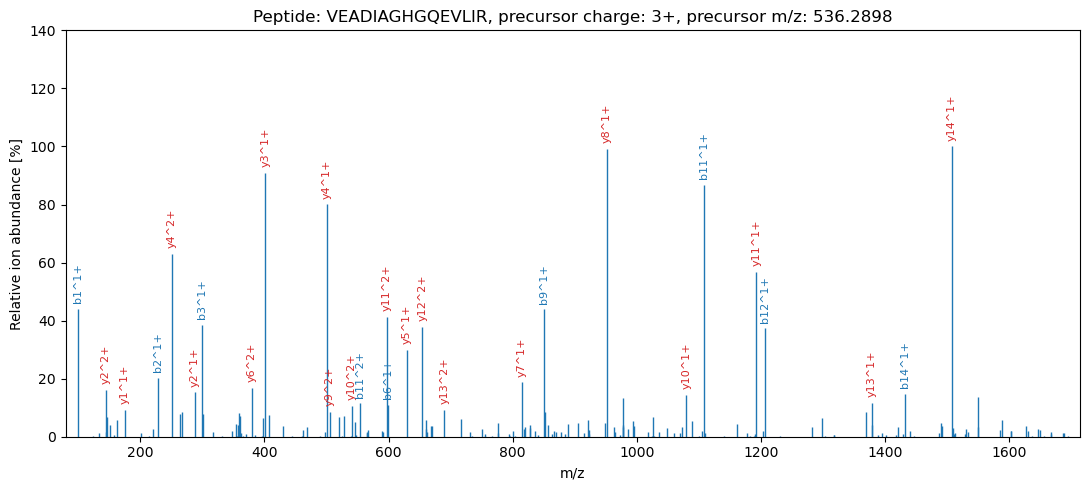

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd

# -----------------------------
# Amino acid monoisotopic masses
# -----------------------------
AA_MASS = {
    "A": 71.03711,
    "R": 156.10111,
    "N": 114.04293,
    "D": 115.02694,
    "C": 103.00919,
    "E": 129.04259,
    "Q": 128.05858,
    "G": 57.02146,
    "H": 137.05891,
    "I": 113.08406,
    "L": 113.08406,
    "K": 128.09496,
    "M": 131.04049,
    "F": 147.06841,
    "P": 97.05276,
    "S": 87.03203,
    "T": 101.04768,
    "W": 186.07931,
    "Y": 163.06333,
    "V": 99.06841,
}

PROTON = 1.007276
H2O = 18.010565


def peptide_mass(sequence):
    """
    Neutral monoisotopic peptide mass.
    Includes H2O for the complete peptide.
    """
    return sum(AA_MASS[aa] for aa in sequence) + H2O


def precursor_mz(sequence, precursor_charge):
    """
    Precursor m/z.
    """
    mass = peptide_mass(sequence)
    return (mass + precursor_charge * PROTON) / precursor_charge


def generate_by_ions(sequence, precursor_charge=2):
    """
    Generate theoretical b and y ions.

    If precursor charge is 3+, generate fragment charges +1 and +2.
    If precursor charge is 2+, generate fragment charge +1.
    """
    ions = []
    n = len(sequence)

    fragment_charges = range(1, precursor_charge)

    for z in fragment_charges:
        # -----------------------------
        # b ions: prefix fragments
        # -----------------------------
        running_mass = 0
        for i in range(1, n):
            running_mass += AA_MASS[sequence[i - 1]]
            mz = (running_mass + z * PROTON) / z

            ions.append({
                "ion": f"b{i}^{z}+",
                "mz": mz,
                "type": "b",
                "charge": z
            })

        # -----------------------------
        # y ions: suffix fragments
        # -----------------------------
        running_mass = 0
        for i in range(1, n):
            running_mass += AA_MASS[sequence[-i]]
            mz = (running_mass + H2O + z * PROTON) / z

            ions.append({
                "ion": f"y{i}^{z}+",
                "mz": mz,
                "type": "y",
                "charge": z
            })

    return ions


def simulate_msms_spectrum(
    sequence,
    precursor_charge=2,
    mz_min=100,
    mz_max=None,
    noise_peaks=120,
    missing_rate=0.25,
    seed=7
):
    np.random.seed(seed)
    random.seed(seed)

    if mz_max is None:
        mz_max = peptide_mass(sequence) + 100

    theoretical_ions = generate_by_ions(
        sequence=sequence,
        precursor_charge=precursor_charge
    )

    peaks = []

    # -----------------------------
    # 1. Add real b/y fragment peaks
    # -----------------------------
    for ion in theoretical_ions:
        if random.random() < missing_rate:
            continue

        mz = ion["mz"]

        if mz < mz_min or mz > mz_max:
            continue

        # Small m/z measurement error
        mz_observed = mz + np.random.normal(0, 0.03)

        # Random but reasonable intensity
        intensity = np.random.gamma(shape=2.0, scale=20.0)

        # Make +1 fragments usually stronger than +2 fragments
        if ion["charge"] == 1:
            intensity *= np.random.uniform(1.0, 1.5)
        else:
            intensity *= np.random.uniform(0.4, 0.9)

        peaks.append({
            "mz": mz_observed,
            "intensity": intensity,
            "ion": ion["ion"],
            "type": ion["type"],
            "charge": ion["charge"],
            "is_fragment": True
        })

    # -----------------------------
    # 2. Add several dominant peaks
    # -----------------------------
    if len(peaks) > 0:
        strong_peak_indices = np.random.choice(
            len(peaks),
            size=min(4, len(peaks)),
            replace=False
        )

        for idx in strong_peak_indices:
            peaks[idx]["intensity"] *= np.random.uniform(2.0, 4.0)

    # -----------------------------
    # 3. Add random noise peaks
    # -----------------------------
    for _ in range(noise_peaks):
        mz = np.random.uniform(mz_min, mz_max)
        intensity = np.random.exponential(scale=4.0)

        peaks.append({
            "mz": mz,
            "intensity": intensity,
            "ion": "",
            "type": "noise",
            "charge": None,
            "is_fragment": False
        })

    # -----------------------------
    # 4. Normalize intensity to 100
    # -----------------------------
    max_intensity = max(p["intensity"] for p in peaks)

    for p in peaks:
        p["intensity"] = p["intensity"] / max_intensity * 100

    peaks = sorted(peaks, key=lambda x: x["mz"])

    return peaks


def plot_spectrum(peaks, sequence, precursor_charge, save_path=None):
    plt.figure(figsize=(11, 5))

    mz_values = [p["mz"] for p in peaks]
    intensities = [p["intensity"] for p in peaks]

    # Draw all peaks
    plt.vlines(mz_values, 0, intensities, linewidth=1)

    # Label major b/y peaks
    for p in peaks:
        if p["is_fragment"] and p["intensity"] > 8:
            color = "tab:blue" if p["type"] == "b" else "tab:red"

            plt.text(
                p["mz"],
                p["intensity"] + 2,
                p["ion"],
                rotation=90,
                ha="center",
                va="bottom",
                fontsize=8,
                color=color
            )

    prec_mz = precursor_mz(sequence, precursor_charge)

    plt.xlabel("m/z")
    plt.ylabel("Relative ion abundance [%]")
    plt.title(
        f"Peptide: {sequence}, precursor charge: {precursor_charge}+, "
        f"precursor m/z: {prec_mz:.4f}"
    )

    plt.ylim(0, 140)
    plt.xlim(min(mz_values) - 20, max(mz_values) + 20)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


# -----------------------------
# Example usage
# -----------------------------
sequence = "VEADIAGHGQEVLIR"
precursor_charge = 3

peaks = simulate_msms_spectrum(
    sequence=sequence,
    precursor_charge=precursor_charge,
    noise_peaks=150,
    missing_rate=0.25,
    seed=25
)

plot_spectrum(
    peaks,
    sequence,
    precursor_charge,
    save_path="simulated_msms_spectrum_with_charge.png"
)

In [6]:
tffc_table = pd.read_excel('/Users/kevinmbp/Desktop/2D_spec_dict/paper/VEA_annot_with_charges.xlsx')
tffc_table['tffc_A'] = (tffc_table['m/z A'] - 1.0072) * tffc_table['charge A']
tffc_table['tffc_B'] = (tffc_table['m/z B'] - 1.0072) * tffc_table['charge B']

# Suppose your original table is called tffc_table

df = tffc_table.copy()

# Create the swapped version

swapped = df.copy()

# Swap A-side and B-side columns

swap_pairs = [

    ("m/z A", "m/z B"),

    ("Interpretation A", "Interpretation B"),

    ("error A", "error B"),

    ("charge A", "charge B"),

    ("tffc_A", "tffc_B"),

]

for col_a, col_b in swap_pairs:

    swapped[col_a], swapped[col_b] = df[col_b], df[col_a]

# Concatenate original + swapped

tffc_table_doubled = pd.concat([df, swapped], ignore_index=True)

# Optional: reset Ranking from 1 to length

#tffc_table_doubled["Ranking"] = range(1, len(tffc_table_doubled) + 1)

tffc_table_doubled

,Ranking,m/z A,Interpretation A,error A,m/z B,Interpretation B,error B,charge A,charge B,tffc_A,tffc_B
0,1,1204.639,internal 3:14 (+1),-0.007,175.120,y1 (+1),-0.001,1.0,1.0,1203.6318,174.1128
1,2,565.275,internal 3:8 (+1),-0.002,814.482,y7 (+1),-0.004,1.0,1.0,564.2678,813.4748
2,3,300.156,b3 (+1),-0.001,654.359,y12 (+2),-0.002,1.0,2.0,299.1488,1306.7036
3,4,879.400,internal 3:11 (+1),-0.004,500.357,y4 (+1),-0.002,1.0,1.0,878.3928,499.3498
4,5,750.357,internal 3:10 (+1),-0.004,629.401,y5 (+1),-0.003,1.0,1.0,749.3498,628.3938
...,...,...,...,...,...,...,...,...,...,...,...
95,46,1008.564,y9 (+1),-0.005,500.237,internal 2:6 (+1),-0.002,1.0,1.0,1007.5568,499.2298
96,47,952.545,y8 (+1) (C13),-0.004,428.216,internal 3:7 (+1),-0.002,1.0,1.0,951.5378,427.2088
97,48,596.846,y11 (+2),-0.002,187.072,internal 3:4 (+1),-0.001,2.0,1.0,1191.6776,186.0648
98,49,596.846,y11 (+2),-0.002,416.187,b4 (+1) (C13),-0.001,2.0,1.0,1191.6776,415.1798


In [17]:
def plot_ffc_map_simple(
    df,
    mz_a_col="mz_A",
    mz_b_col="mz_B",
    lines=None,
    b_ions=None,
    y_ions=None,
    xlim=None,
    ylim=None,
    start_from_zero=True,
    figsize=(8, 7),
    point_size=42,
    point_color="#2f6690",       # deep muted slate-blue (was harsh "blue")
    point_alpha=0.80,
    point_edgecolor="white",     # white halo separates overlapping points (was "cyan")
    point_linewidth=0.6,
    line_color="#c45b4c",        # warm brick accent for diagonal/charge lines
    line_alpha=0.55,
    solid_grid_color="#9aa3ad",  # neutral cool gray, recedes behind data
    grid_alpha=0.18,
    grid_linewidth=0.8,
    grid_label_alpha=0.55,
    grid_label_fontsize=7,
    show_grid_labels=True,
    dashed_grid_color="#7e93ab", # blue-gray: distinct from solid, not fighting the dots
    dashed_grid_alpha=0.55,
    spine_color="#cfd4d9",
    tick_color="#5a5f66",
):
    """
    Plot an FFC map with uniform-color dots (no ranking colorbar).
 
    Full b/y ion grids on all four sides:
      - b-ions: solid vertical lines (labels at bottom)
                dashed horizontal lines (labels at right)
      - y-ions: solid horizontal lines (labels at left)
                dashed vertical lines (labels at top)
 
    If lines=None, no diagonal/charge lines will be drawn.
 
    Visual design:
      - Data points are the clear focal point (dark, saturated, with a white edge).
      - Grid families recede (light, desaturated); solid vs dashed is read by
        linestyle + a subtle tone shift, so neither competes with the data.
    """
 
    data = df.copy()
 
    data[mz_a_col] = pd.to_numeric(data[mz_a_col], errors="coerce")
    data[mz_b_col] = pd.to_numeric(data[mz_b_col], errors="coerce")
 
    data = data.dropna(subset=[mz_a_col, mz_b_col])
 
    if data.empty:
        raise ValueError("No valid data points remain after cleaning the dataframe.")
 
    # Determine plot ranges
    if xlim is None:
        if start_from_zero:
            xlim = (0, data[mz_a_col].max() + 300)
        else:
            xlim = (data[mz_a_col].min() - 50, data[mz_a_col].max() + 300)
 
    if ylim is None:
        if start_from_zero:
            ylim = (0, data[mz_b_col].max() + 300)
        else:
            ylim = (data[mz_b_col].min() - 50, data[mz_b_col].max() + 300)
 
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.set_axisbelow(True)
 
    # ------------------------------------------------------------
    # Label offsets — all labels sit OUTSIDE the plot area
    # ------------------------------------------------------------
 
    # b-ion solid vertical → labels below x-axis
    bottom_label_y = ylim[0] - 0.02 * (ylim[1] - ylim[0])
    # y-ion solid horizontal → labels left of y-axis
    left_label_x   = xlim[0] - 0.01 * (xlim[1] - xlim[0])
    # y-ion dashed vertical → labels above top edge
    top_label_y    = ylim[1] + 0.01 * (ylim[1] - ylim[0])
    # b-ion dashed horizontal → labels right of right edge
    right_label_x  = xlim[1] + 0.01 * (xlim[1] - xlim[0])
 
    # ------------------------------------------------------------
    # b-ions: solid vertical (bottom) + dashed horizontal (right)
    # ------------------------------------------------------------
 
    if b_ions is not None:
        for ion_name, mz_value in b_ions.items():
            mz_value = float(mz_value)
 
            # Solid vertical line, label below
            if xlim[0] <= mz_value <= xlim[1]:
                ax.axvline(
                    x=mz_value, color=solid_grid_color, alpha=grid_alpha,
                    linewidth=grid_linewidth, linestyle="-", zorder=0,
                )
                if show_grid_labels:
                    ax.text(
                        mz_value, bottom_label_y, ion_name,
                        color=solid_grid_color, alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize, rotation=90,
                        ha="center", va="top", zorder=1,
                        clip_on=False,
                    )
 
            # Dashed horizontal line, label at right outside
            if ylim[0] <= mz_value <= ylim[1]:
                ax.axhline(
                    y=mz_value, color=dashed_grid_color, alpha=dashed_grid_alpha,
                    linewidth=grid_linewidth, linestyle="--", zorder=0,
                )
                if show_grid_labels:
                    ax.text(
                        right_label_x, mz_value, ion_name,
                        color=dashed_grid_color, alpha=dashed_grid_alpha,
                        fontsize=grid_label_fontsize,
                        ha="left", va="center", zorder=1,
                        clip_on=False,
                    )
 
    # ------------------------------------------------------------
    # y-ions: solid horizontal (left) + dashed vertical (top)
    # ------------------------------------------------------------
 
    if y_ions is not None:
        for ion_name, mz_value in y_ions.items():
            mz_value = float(mz_value)
 
            # Solid horizontal line, label at left outside
            if ylim[0] <= mz_value <= ylim[1]:
                ax.axhline(
                    y=mz_value, color=solid_grid_color, alpha=grid_alpha,
                    linewidth=grid_linewidth, linestyle="-", zorder=0,
                )
                if show_grid_labels:
                    ax.text(
                        left_label_x, mz_value, ion_name,
                        color=solid_grid_color, alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize,
                        ha="right", va="center", zorder=1,
                        clip_on=False,
                    )
 
            # Dashed vertical line, label at top outside
            if xlim[0] <= mz_value <= xlim[1]:
                ax.axvline(
                    x=mz_value, color=dashed_grid_color, alpha=dashed_grid_alpha,
                    linewidth=grid_linewidth, linestyle="--", zorder=0,
                )
                if show_grid_labels:
                    ax.text(
                        mz_value, top_label_y, ion_name,
                        color=dashed_grid_color, alpha=dashed_grid_alpha,
                        fontsize=grid_label_fontsize, rotation=90,
                        ha="center", va="bottom", zorder=1,
                        clip_on=False,
                    )
 
    # ------------------------------------------------------------
    # Scatter plot — uniform color, clean white edge
    # ------------------------------------------------------------
 
    ax.scatter(
        data[mz_a_col],
        data[mz_b_col],
        s=point_size,
        c=point_color,
        edgecolors=point_edgecolor,
        linewidths=point_linewidth,
        alpha=point_alpha,
        zorder=3,
    )
 
    # ------------------------------------------------------------
    # Draw main diagonal/charge lines only if provided
    # ------------------------------------------------------------
 
    if lines is not None:
        x_values = np.linspace(xlim[0], xlim[1], 500)
 
        for line in lines:
            slope = line.get("slope")
            intercept = line.get("intercept")
            color = line.get("color", line_color)
            label = line.get("label", None)
 
            y_values = slope * x_values + intercept
 
            ax.plot(
                x_values,
                y_values,
                color=color,
                alpha=line_alpha,
                linewidth=2,
                label=label,
                zorder=2,
            )
 
        if any(line.get("label") is not None for line in lines):
            ax.legend(
                loc="lower left",
                bbox_to_anchor=(0.0, 1.08),
                fontsize=10,
                framealpha=0.95,
                edgecolor="#dfe3e8",
                ncol=2,
            )
 
    # ------------------------------------------------------------
    # Axis labels and formatting
    # ------------------------------------------------------------
 
    ax.set_xlabel("m/z A", fontsize=14, labelpad=20, color="#2b2f33")
    ax.set_ylabel("m/z B", fontsize=14, labelpad=20, color="#2b2f33")
 
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
 
    # Soften the frame so it doesn't box the data in heavily
    for spine in ax.spines.values():
        spine.set_color(spine_color)
        spine.set_linewidth(0.9)
 
    ax.tick_params(axis="x", labelsize=12, pad=23, colors=tick_color)
    ax.tick_params(axis="y", labelsize=12, pad=23, colors=tick_color)
 
    plt.tight_layout()
    plt.subplots_adjust(left=0.15, right=0.88, top=0.85, bottom=0.15)
    plt.show()
 
    return fig, ax

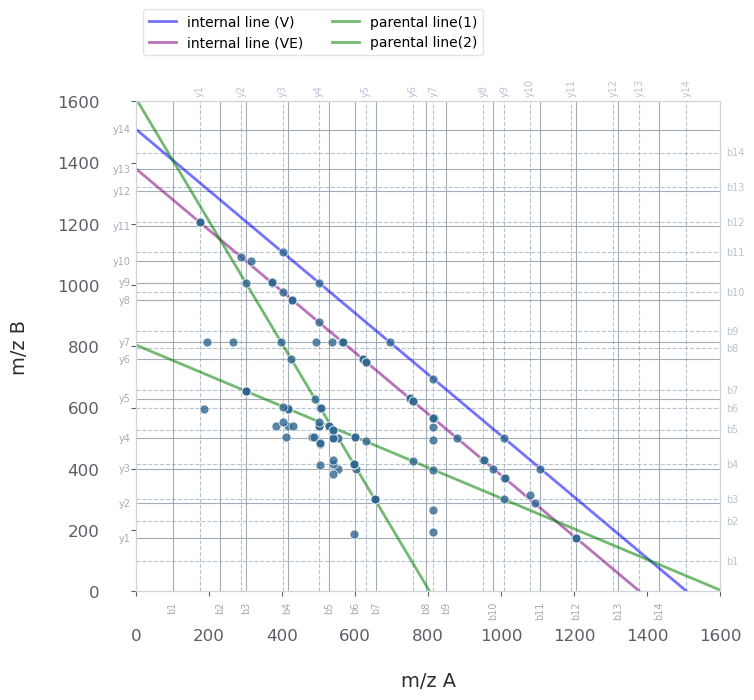

(<Figure size 800x700 with 1 Axes>, <Axes: xlabel='m/z A', ylabel='m/z B'>)

In [22]:
import peptide
PEP_SEQ = "VEADIAGHGQEVLIR"
CHARGE = 3
pep = peptide.Pep(f"[{PEP_SEQ}+{CHARGE}H]{CHARGE}+", end_h20=True)

b_ions = {f'b{i}':pep.ion_mass(f'b{i}') for i in range(1, len(PEP_SEQ))}
y_ions = {f'y{i}':pep.ion_mass(f'y{i}') for i in range(1, len(PEP_SEQ))}

exact_lines = [
    {"slope": -1, "intercept": 1608.869 - 100.069, "color": "blue",   "label": "internal line (V)"},
    {"slope": -1, "intercept": 1608.869 - 229.112, "color": "purple", "label": "internal line (VE)"},
    {"slope": -0.5, "intercept": 1608.869 / 2,     "color": "green",  "label": "parental line(1)"},
    {"slope": -2,   "intercept": 1608.869,          "color": "green",  "label": "parental line(2)"}
]

plot_ffc_map_simple(
    tffc_table_doubled,
    mz_a_col="m/z A",
    mz_b_col="m/z B",
    lines=exact_lines,
    b_ions=b_ions,
    y_ions=y_ions,
    start_from_zero=True,
    grid_alpha=0.9,
    grid_label_alpha=0.9,
    grid_label_fontsize=7,
    xlim=(0, 1600),
    ylim=(0, 1600)
)

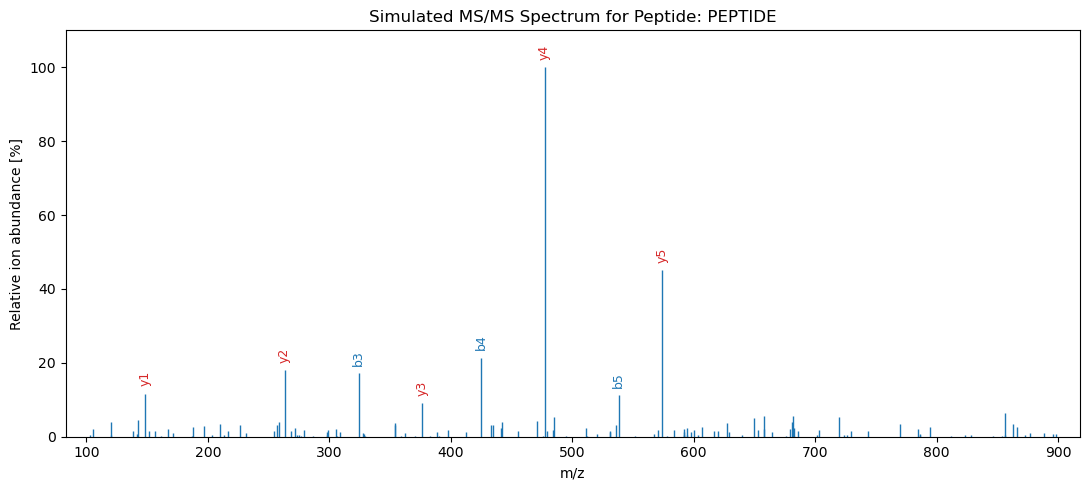

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import random

# -----------------------------
# Amino acid monoisotopic masses
# -----------------------------
AA_MASS = {
    "A": 71.03711,
    "R": 156.10111,
    "N": 114.04293,
    "D": 115.02694,
    "C": 103.00919,
    "E": 129.04259,
    "Q": 128.05858,
    "G": 57.02146,
    "H": 137.05891,
    "I": 113.08406,
    "L": 113.08406,
    "K": 128.09496,
    "M": 131.04049,
    "F": 147.06841,
    "P": 97.05276,
    "S": 87.03203,
    "T": 101.04768,
    "W": 186.07931,
    "Y": 163.06333,
    "V": 99.06841,
}

PROTON = 1.007276
H2O = 18.010565


def peptide_mass(sequence):
    """
    Neutral monoisotopic peptide mass.
    Includes H2O because a complete peptide has N- and C-termini.
    """
    return sum(AA_MASS[aa] for aa in sequence) + H2O


def generate_by_ions(sequence, charge=1):
    """
    Generate theoretical b and y ions for a peptide.
    Default charge is +1.
    """
    b_ions = []
    y_ions = []

    n = len(sequence)

    # b ions: prefix fragments
    running_mass = 0
    for i in range(1, n):
        running_mass += AA_MASS[sequence[i - 1]]
        mz = (running_mass + charge * PROTON) / charge
        b_ions.append({
            "ion": f"b{i}",
            "mz": mz,
            "type": "b"
        })

    # y ions: suffix fragments
    running_mass = 0
    for i in range(1, n):
        running_mass += AA_MASS[sequence[-i]]
        mz = (running_mass + H2O + charge * PROTON) / charge
        y_ions.append({
            "ion": f"y{i}",
            "mz": mz,
            "type": "y"
        })

    return b_ions + y_ions


def simulate_msms_spectrum(
    sequence,
    mz_min=100,
    mz_max=None,
    noise_peaks=120,
    missing_rate=0.25,
    seed=7
):
    np.random.seed(seed)
    random.seed(seed)

    if mz_max is None:
        mz_max = peptide_mass(sequence) + 100

    theoretical_ions = generate_by_ions(sequence, charge=1)

    peaks = []

    # -----------------------------
    # 1. Add real b/y fragment peaks
    # -----------------------------
    for ion in theoretical_ions:
        if random.random() < missing_rate:
            continue

        mz = ion["mz"]

        if mz < mz_min or mz > mz_max:
            continue

        # Add small m/z measurement error
        mz_observed = mz + np.random.normal(0, 0.03)

        # Fragment intensity: random but reasonable
        intensity = np.random.gamma(shape=2.0, scale=20.0)

        peaks.append({
            "mz": mz_observed,
            "intensity": intensity,
            "ion": ion["ion"],
            "type": ion["type"],
            "is_fragment": True
        })

    # -----------------------------
    # 2. Add several very strong peaks
    # -----------------------------
    if len(peaks) > 0:
        strong_peak_indices = np.random.choice(
            len(peaks),
            size=min(4, len(peaks)),
            replace=False
        )

        for idx in strong_peak_indices:
            peaks[idx]["intensity"] *= np.random.uniform(2.0, 4.0)

    # -----------------------------
    # 3. Add random noise peaks
    # -----------------------------
    for _ in range(noise_peaks):
        mz = np.random.uniform(mz_min, mz_max)

        # Mostly small intensities
        intensity = np.random.exponential(scale=4.0)

        peaks.append({
            "mz": mz,
            "intensity": intensity,
            "ion": "",
            "type": "noise",
            "is_fragment": False
        })

    # -----------------------------
    # 4. Normalize intensity to 100
    # -----------------------------
    max_intensity = max(p["intensity"] for p in peaks)

    for p in peaks:
        p["intensity"] = p["intensity"] / max_intensity * 100

    peaks = sorted(peaks, key=lambda x: x["mz"])

    return peaks


def plot_spectrum(peaks, sequence, save_path=None):
    plt.figure(figsize=(11, 5))

    mz_values = [p["mz"] for p in peaks]
    intensities = [p["intensity"] for p in peaks]

    # Plot all peaks
    plt.vlines(mz_values, 0, intensities, linewidth=1)

    # Label major b/y peaks
    for p in peaks:
        if p["is_fragment"] and p["intensity"] > 8:
            color = "tab:blue" if p["type"] == "b" else "tab:red"

            plt.text(
                p["mz"],
                p["intensity"] + 2,
                p["ion"],
                rotation=90,
                ha="center",
                va="bottom",
                fontsize=9,
                color=color
            )

    plt.xlabel("m/z")
    plt.ylabel("Relative ion abundance [%]")
    plt.title(f"Simulated MS/MS Spectrum for Peptide: {sequence}")

    plt.ylim(0, 110)
    plt.xlim(min(mz_values) - 20, max(mz_values) + 20)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


# -----------------------------
# Example usage
# -----------------------------
sequence = "PEPTIDE"   # You can replace this with your own peptide

peaks = simulate_msms_spectrum(
    sequence=sequence,
    noise_peaks=130,
    missing_rate=0.02,
    seed=15
)

plot_spectrum(
    peaks,
    sequence,
    save_path="simulated_msms_spectrum.png"
)

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_ffc_map_simple_no_line(
    df,
    mz_a_col="mz_A",
    mz_b_col="mz_B",
    b_ions=None,
    y_ions=None,
    xlim=None,
    ylim=None,
    start_from_zero=True,
    figsize=(12, 12),
    point_size=64,
    point_color="#2f6690",
    point_alpha=0.85,
    point_edgecolor="white",
    point_linewidth=0.8,
    solid_grid_color="#9aa3ad",
    grid_alpha=0.22,
    grid_linewidth=1.0,
    grid_label_alpha=0.65,
    grid_label_fontsize=9,
    show_grid_labels=True,
    dashed_grid_color="#7e93ab",
    dashed_grid_alpha=0.60,
    spine_color="#cfd4d9",
    tick_color="#5a5f66",
    axis_label_fontsize=18,
    tick_label_fontsize=14,
    save_path=None,
    save_dpi=300,
    show=True,
):
    """
    Plot an FFC map with uniform-color dots.

    Full b/y ion grids on all four sides:
      - b-ions: solid vertical lines with labels at bottom
                dashed horizontal lines with labels at right
      - y-ions: solid horizontal lines with labels at left
                dashed vertical lines with labels at top

    No diagonal/charge lines are drawn.

    Recommended saving:
      - For slides: save_path="ffc_map.png", save_dpi=300
      - For publication/vector: save_path="ffc_map.pdf" or "ffc_map.svg"
    """

    data = df.copy()

    data[mz_a_col] = pd.to_numeric(data[mz_a_col], errors="coerce")
    data[mz_b_col] = pd.to_numeric(data[mz_b_col], errors="coerce")

    data = data.dropna(subset=[mz_a_col, mz_b_col])

    if data.empty:
        raise ValueError("No valid data points remain after cleaning the dataframe.")

    # ------------------------------------------------------------
    # Determine plot ranges
    # ------------------------------------------------------------

    if xlim is None:
        if start_from_zero:
            xlim = (0, data[mz_a_col].max() + 300)
        else:
            xlim = (data[mz_a_col].min() - 50, data[mz_a_col].max() + 300)

    if ylim is None:
        if start_from_zero:
            ylim = (0, data[mz_b_col].max() + 300)
        else:
            ylim = (data[mz_b_col].min() - 50, data[mz_b_col].max() + 300)

    # Make x/y numeric ranges equal so the plot is geometrically square
    x_span = xlim[1] - xlim[0]
    y_span = ylim[1] - ylim[0]

    if x_span != y_span:
        max_span = max(x_span, y_span)

        x_center = (xlim[0] + xlim[1]) / 2
        y_center = (ylim[0] + ylim[1]) / 2

        xlim = (x_center - max_span / 2, x_center + max_span / 2)
        ylim = (y_center - max_span / 2, y_center + max_span / 2)

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.set_axisbelow(True)

    # ------------------------------------------------------------
    # Label offsets — all labels sit OUTSIDE the plot area
    # ------------------------------------------------------------

    bottom_label_y = ylim[0] - 0.025 * (ylim[1] - ylim[0])
    left_label_x = xlim[0] - 0.015 * (xlim[1] - xlim[0])
    top_label_y = ylim[1] + 0.012 * (ylim[1] - ylim[0])
    right_label_x = xlim[1] + 0.012 * (xlim[1] - xlim[0])

    # ------------------------------------------------------------
    # b-ions: solid vertical bottom + dashed horizontal right
    # ------------------------------------------------------------

    if b_ions is not None:
        for ion_name, mz_value in b_ions.items():
            mz_value = float(mz_value)

            # Solid vertical line, label below
            if xlim[0] <= mz_value <= xlim[1]:
                ax.axvline(
                    x=mz_value,
                    color=solid_grid_color,
                    alpha=grid_alpha,
                    linewidth=grid_linewidth,
                    linestyle="-",
                    zorder=0,
                )

                if show_grid_labels:
                    ax.text(
                        mz_value,
                        bottom_label_y,
                        ion_name,
                        color=solid_grid_color,
                        alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize,
                        rotation=90,
                        ha="center",
                        va="top",
                        zorder=1,
                        clip_on=False,
                    )

            # Dashed horizontal line, label at right
            if ylim[0] <= mz_value <= ylim[1]:
                ax.axhline(
                    y=mz_value,
                    color=dashed_grid_color,
                    alpha=dashed_grid_alpha,
                    linewidth=grid_linewidth,
                    linestyle="--",
                    zorder=0,
                )

                if show_grid_labels:
                    ax.text(
                        right_label_x,
                        mz_value,
                        ion_name,
                        color=dashed_grid_color,
                        alpha=dashed_grid_alpha,
                        fontsize=grid_label_fontsize,
                        ha="left",
                        va="center",
                        zorder=1,
                        clip_on=False,
                    )

    # ------------------------------------------------------------
    # y-ions: solid horizontal left + dashed vertical top
    # ------------------------------------------------------------

    if y_ions is not None:
        for ion_name, mz_value in y_ions.items():
            mz_value = float(mz_value)

            # Solid horizontal line, label at left
            if ylim[0] <= mz_value <= ylim[1]:
                ax.axhline(
                    y=mz_value,
                    color=solid_grid_color,
                    alpha=grid_alpha,
                    linewidth=grid_linewidth,
                    linestyle="-",
                    zorder=0,
                )

                if show_grid_labels:
                    ax.text(
                        left_label_x,
                        mz_value,
                        ion_name,
                        color=solid_grid_color,
                        alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize,
                        ha="right",
                        va="center",
                        zorder=1,
                        clip_on=False,
                    )

            # Dashed vertical line, label at top
            if xlim[0] <= mz_value <= xlim[1]:
                ax.axvline(
                    x=mz_value,
                    color=dashed_grid_color,
                    alpha=dashed_grid_alpha,
                    linewidth=grid_linewidth,
                    linestyle="--",
                    zorder=0,
                )

                if show_grid_labels:
                    ax.text(
                        mz_value,
                        top_label_y,
                        ion_name,
                        color=dashed_grid_color,
                        alpha=dashed_grid_alpha,
                        fontsize=grid_label_fontsize,
                        rotation=90,
                        ha="center",
                        va="bottom",
                        zorder=1,
                        clip_on=False,
                    )

    # ------------------------------------------------------------
    # Scatter plot
    # ------------------------------------------------------------

    ax.scatter(
        data[mz_a_col],
        data[mz_b_col],
        s=point_size,
        c=point_color,
        edgecolors=point_edgecolor,
        linewidths=point_linewidth,
        alpha=point_alpha,
        zorder=3,
    )

    # ------------------------------------------------------------
    # Axis labels and formatting
    # ------------------------------------------------------------

    ax.set_xlabel(
        "m/z A",
        fontsize=axis_label_fontsize,
        labelpad=26,
        color="#2b2f33",
    )

    ax.set_ylabel(
        "m/z B",
        fontsize=axis_label_fontsize,
        labelpad=26,
        color="#2b2f33",
    )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Make one unit on x equal one unit on y
    ax.set_aspect("equal", adjustable="box")

    # Soften the frame
    for spine in ax.spines.values():
        spine.set_color(spine_color)
        spine.set_linewidth(1.0)

    ax.tick_params(
        axis="x",
        labelsize=tick_label_fontsize,
        pad=28,
        colors=tick_color,
    )

    ax.tick_params(
        axis="y",
        labelsize=tick_label_fontsize,
        pad=28,
        colors=tick_color,
    )

    # Manual spacing for outside labels.
    # Do not use tight_layout(), because it can squeeze the square plot area.
    plt.subplots_adjust(
        left=0.16,
        right=0.86,
        top=0.86,
        bottom=0.16,
    )

    # ------------------------------------------------------------
    # Save high-resolution figure
    # ------------------------------------------------------------

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=save_dpi,
            bbox_inches="tight",
            facecolor="white",
        )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax

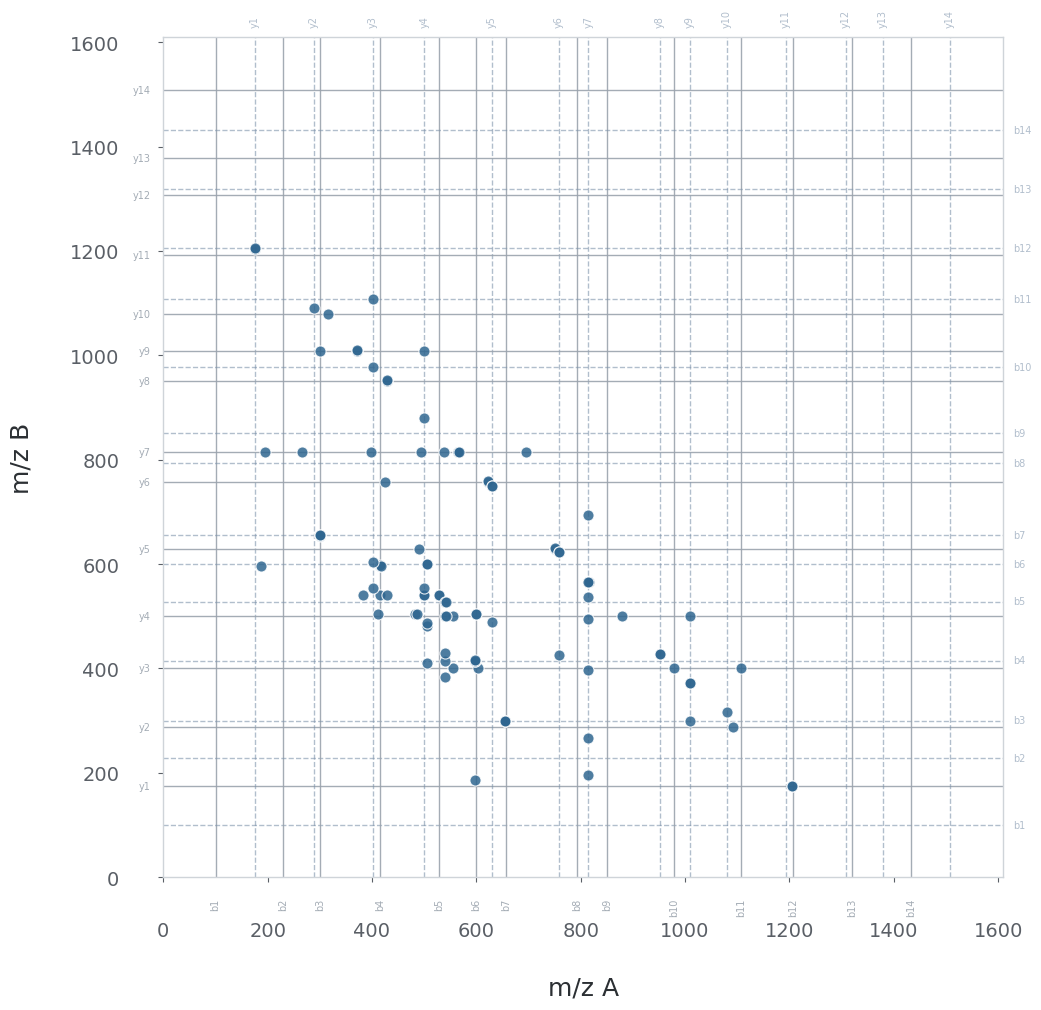

(<Figure size 1200x1200 with 1 Axes>, <Axes: xlabel='m/z A', ylabel='m/z B'>)

In [35]:
plot_ffc_map_simple_no_line(
    tffc_table_doubled,
    mz_a_col="m/z A",
    mz_b_col="m/z B",
    b_ions=b_ions,
    y_ions=y_ions,
    start_from_zero=True,
    grid_alpha=0.9,
    grid_label_alpha=0.9,
    grid_label_fontsize=7,
    xlim=(0, 1610),
    ylim=(0, 1610),
    save_path="ffc_map_large.png",
    save_dpi=300,
)

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_ffc_map_simple_with_line(
    df,
    mz_a_col="mz_A",
    mz_b_col="mz_B",
    lines=None,
    b_ions=None,
    y_ions=None,
    xlim=None,
    ylim=None,
    start_from_zero=True,
    figsize=(12, 12),
    point_size=64,
    point_color="#2f6690",
    point_alpha=0.85,
    point_edgecolor="white",
    point_linewidth=0.8,
    line_color="#c45b4c",
    line_alpha=0.65,
    line_width=2.2,
    solid_grid_color="#9aa3ad",
    grid_alpha=0.22,
    grid_linewidth=1.0,
    grid_label_alpha=0.65,
    grid_label_fontsize=9,
    show_grid_labels=True,
    dashed_grid_color="#7e93ab",
    dashed_grid_alpha=0.60,
    spine_color="#cfd4d9",
    tick_color="#5a5f66",
    axis_label_fontsize=18,
    tick_label_fontsize=14,
    save_path=None,
    save_dpi=300,
    show=True,
):
    """
    Plot an FFC map with uniform-color dots, b/y ion grids, and optional lines.

    Full b/y ion grids on all four sides:
      - b-ions: solid vertical lines with labels at bottom
                dashed horizontal lines with labels at right
      - y-ions: solid horizontal lines with labels at left
                dashed vertical lines with labels at top

    Optional line format:
        lines = [
            {"slope": -1, "intercept": 1609, "label": "parental line"},
            {"slope": -1, "intercept": 1610, "label": "isotopic line"},
        ]

    You can also customize each line:
        lines = [
            {
                "slope": -1,
                "intercept": 1609,
                "label": "parental line",
                "color": "#c45b4c",
                "alpha": 0.8,
                "linewidth": 2.5,
                "linestyle": "-",
            }
        ]

    Recommended saving:
      - For slides: save_path="ffc_map.png", save_dpi=300
      - For publication/vector: save_path="ffc_map.pdf" or "ffc_map.svg"
    """

    data = df.copy()

    data[mz_a_col] = pd.to_numeric(data[mz_a_col], errors="coerce")
    data[mz_b_col] = pd.to_numeric(data[mz_b_col], errors="coerce")

    data = data.dropna(subset=[mz_a_col, mz_b_col])

    if data.empty:
        raise ValueError("No valid data points remain after cleaning the dataframe.")

    # ------------------------------------------------------------
    # Determine plot ranges
    # ------------------------------------------------------------

    if xlim is None:
        if start_from_zero:
            xlim = (0, data[mz_a_col].max() + 300)
        else:
            xlim = (data[mz_a_col].min() - 50, data[mz_a_col].max() + 300)

    if ylim is None:
        if start_from_zero:
            ylim = (0, data[mz_b_col].max() + 300)
        else:
            ylim = (data[mz_b_col].min() - 50, data[mz_b_col].max() + 300)

    # Make x/y numeric ranges equal so the plot is geometrically square
    x_span = xlim[1] - xlim[0]
    y_span = ylim[1] - ylim[0]

    if x_span != y_span:
        max_span = max(x_span, y_span)

        x_center = (xlim[0] + xlim[1]) / 2
        y_center = (ylim[0] + ylim[1]) / 2

        xlim = (x_center - max_span / 2, x_center + max_span / 2)
        ylim = (y_center - max_span / 2, y_center + max_span / 2)

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.set_axisbelow(True)

    # ------------------------------------------------------------
    # Label offsets — all labels sit OUTSIDE the plot area
    # ------------------------------------------------------------

    bottom_label_y = ylim[0] - 0.025 * (ylim[1] - ylim[0])
    left_label_x = xlim[0] - 0.015 * (xlim[1] - xlim[0])
    top_label_y = ylim[1] + 0.012 * (ylim[1] - ylim[0])
    right_label_x = xlim[1] + 0.012 * (xlim[1] - xlim[0])

    # ------------------------------------------------------------
    # b-ions: solid vertical bottom + dashed horizontal right
    # ------------------------------------------------------------

    if b_ions is not None:
        for ion_name, mz_value in b_ions.items():
            mz_value = float(mz_value)

            # Solid vertical line, label below
            if xlim[0] <= mz_value <= xlim[1]:
                ax.axvline(
                    x=mz_value,
                    color=solid_grid_color,
                    alpha=grid_alpha,
                    linewidth=grid_linewidth,
                    linestyle="-",
                    zorder=0,
                )

                if show_grid_labels:
                    ax.text(
                        mz_value,
                        bottom_label_y,
                        ion_name,
                        color=solid_grid_color,
                        alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize,
                        rotation=90,
                        ha="center",
                        va="top",
                        zorder=1,
                        clip_on=False,
                    )

            # Dashed horizontal line, label at right
            if ylim[0] <= mz_value <= ylim[1]:
                ax.axhline(
                    y=mz_value,
                    color=dashed_grid_color,
                    alpha=dashed_grid_alpha,
                    linewidth=grid_linewidth,
                    linestyle="--",
                    zorder=0,
                )

                if show_grid_labels:
                    ax.text(
                        right_label_x,
                        mz_value,
                        ion_name,
                        color=dashed_grid_color,
                        alpha=dashed_grid_alpha,
                        fontsize=grid_label_fontsize,
                        ha="left",
                        va="center",
                        zorder=1,
                        clip_on=False,
                    )

    # ------------------------------------------------------------
    # y-ions: solid horizontal left + dashed vertical top
    # ------------------------------------------------------------

    if y_ions is not None:
        for ion_name, mz_value in y_ions.items():
            mz_value = float(mz_value)

            # Solid horizontal line, label at left
            if ylim[0] <= mz_value <= ylim[1]:
                ax.axhline(
                    y=mz_value,
                    color=solid_grid_color,
                    alpha=grid_alpha,
                    linewidth=grid_linewidth,
                    linestyle="-",
                    zorder=0,
                )

                if show_grid_labels:
                    ax.text(
                        left_label_x,
                        mz_value,
                        ion_name,
                        color=solid_grid_color,
                        alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize,
                        ha="right",
                        va="center",
                        zorder=1,
                        clip_on=False,
                    )

            # Dashed vertical line, label at top
            if xlim[0] <= mz_value <= xlim[1]:
                ax.axvline(
                    x=mz_value,
                    color=dashed_grid_color,
                    alpha=dashed_grid_alpha,
                    linewidth=grid_linewidth,
                    linestyle="--",
                    zorder=0,
                )

                if show_grid_labels:
                    ax.text(
                        mz_value,
                        top_label_y,
                        ion_name,
                        color=dashed_grid_color,
                        alpha=dashed_grid_alpha,
                        fontsize=grid_label_fontsize,
                        rotation=90,
                        ha="center",
                        va="bottom",
                        zorder=1,
                        clip_on=False,
                    )

    # ------------------------------------------------------------
    # Draw optional diagonal/charge lines
    # ------------------------------------------------------------

    if lines is not None:
        x_values = np.linspace(xlim[0], xlim[1], 1000)

        for line in lines:
            slope = line.get("slope")
            intercept = line.get("intercept")

            if slope is None or intercept is None:
                raise ValueError(
                    "Each line must contain at least 'slope' and 'intercept'."
                )

            color = line.get("color", line_color)
            alpha = line.get("alpha", line_alpha)
            linewidth = line.get("linewidth", line_width)
            linestyle = line.get("linestyle", "-")
            label = line.get("label", None)

            y_values = slope * x_values + intercept

            # Only draw the portion that falls inside the current y-limits
            mask = (y_values >= ylim[0]) & (y_values <= ylim[1])

            ax.plot(
                x_values[mask],
                y_values[mask],
                color=color,
                alpha=alpha,
                linewidth=linewidth,
                linestyle=linestyle,
                label=label,
                zorder=2,
            )

        if any(line.get("label") is not None for line in lines):
            ax.legend(
                loc="lower left",
                bbox_to_anchor=(0.0, 1.08),
                fontsize=12,
                framealpha=0.95,
                edgecolor="#dfe3e8",
                ncol=2,
            )

    # ------------------------------------------------------------
    # Scatter plot
    # ------------------------------------------------------------

    ax.scatter(
        data[mz_a_col],
        data[mz_b_col],
        s=point_size,
        c=point_color,
        edgecolors=point_edgecolor,
        linewidths=point_linewidth,
        alpha=point_alpha,
        zorder=3,
    )

    # ------------------------------------------------------------
    # Axis labels and formatting
    # ------------------------------------------------------------

    ax.set_xlabel(
        "m/z A",
        fontsize=axis_label_fontsize,
        labelpad=26,
        color="#2b2f33",
    )

    ax.set_ylabel(
        "m/z B",
        fontsize=axis_label_fontsize,
        labelpad=26,
        color="#2b2f33",
    )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Make one unit on x equal one unit on y
    ax.set_aspect("equal", adjustable="box")

    # Soften the frame
    for spine in ax.spines.values():
        spine.set_color(spine_color)
        spine.set_linewidth(1.0)

    ax.tick_params(
        axis="x",
        labelsize=tick_label_fontsize,
        pad=28,
        colors=tick_color,
    )

    ax.tick_params(
        axis="y",
        labelsize=tick_label_fontsize,
        pad=28,
        colors=tick_color,
    )

    # Manual spacing for outside labels.
    # Do not use tight_layout(), because it can squeeze the square plot area.
    plt.subplots_adjust(
        left=0.16,
        right=0.86,
        top=0.86,
        bottom=0.16,
    )

    # ------------------------------------------------------------
    # Save high-resolution figure
    # ------------------------------------------------------------

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=save_dpi,
            bbox_inches="tight",
            facecolor="white",
        )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax

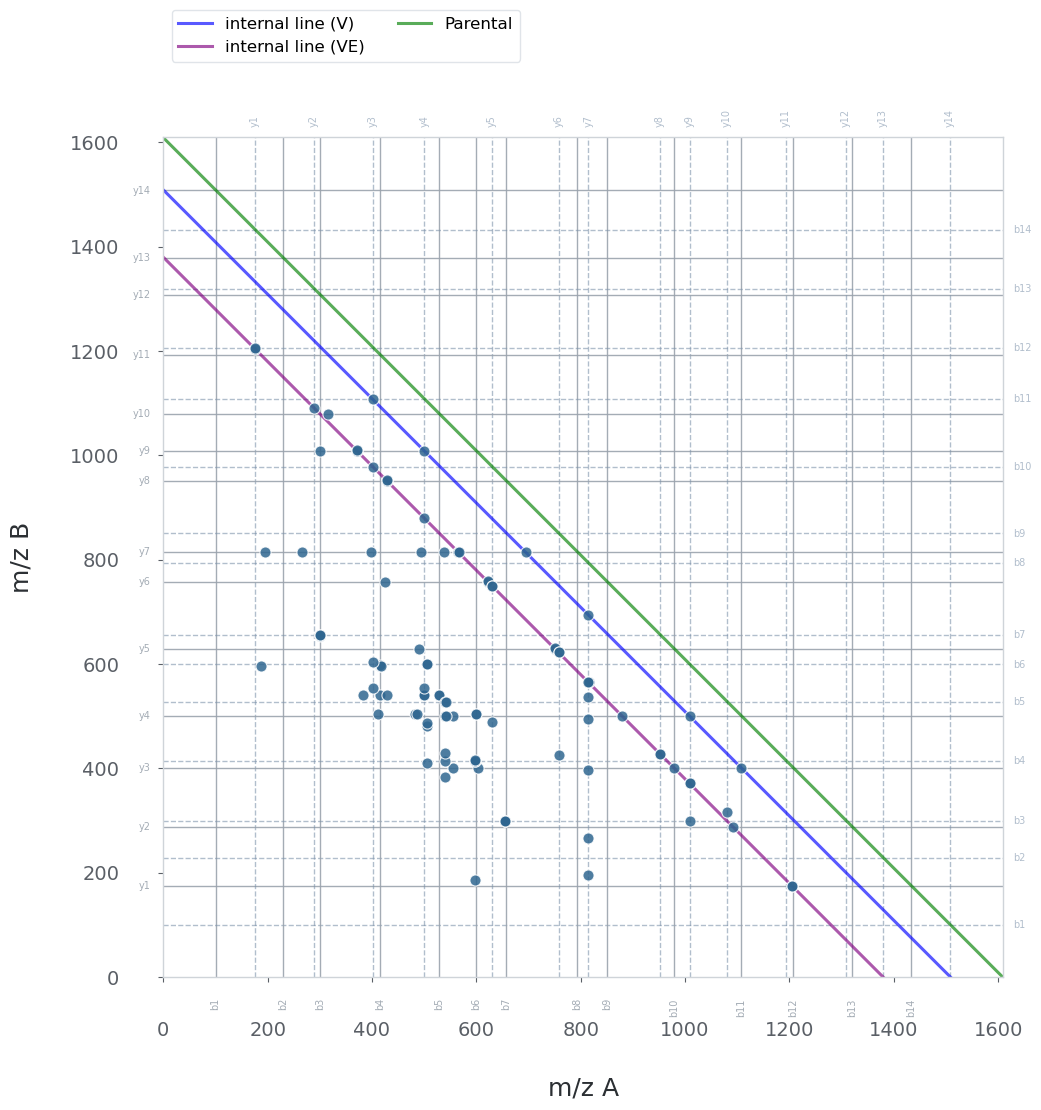

(<Figure size 1200x1200 with 1 Axes>, <Axes: xlabel='m/z A', ylabel='m/z B'>)

In [42]:
plot_ffc_map_simple_with_line(
    tffc_table_doubled,
    mz_a_col="m/z A",
    mz_b_col="m/z B",
    lines=exact_lines,
    b_ions=b_ions,
    y_ions=y_ions,
    start_from_zero=True,
    grid_alpha=0.9,
    grid_label_alpha=0.9,
    grid_label_fontsize=7,
    xlim=(0, 1610),
    ylim=(0, 1610)
)

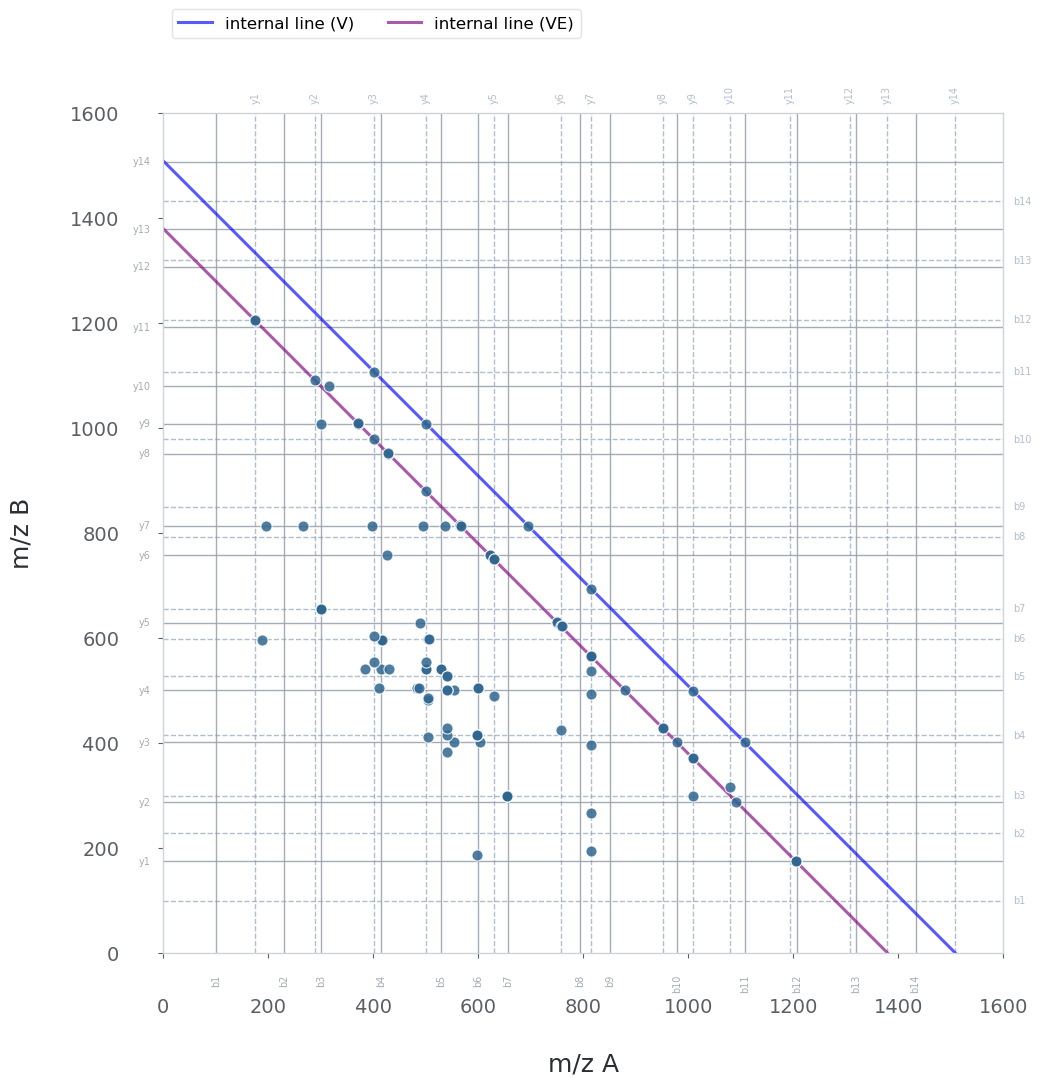

(<Figure size 1200x1200 with 1 Axes>, <Axes: xlabel='m/z A', ylabel='m/z B'>)

In [38]:
exact_lines = [
    {"slope": -1, "intercept": 1608.869 - 100.069, "color": "blue",   "label": "internal line (V)"},
    {"slope": -1, "intercept": 1608.869 - 229.112, "color": "purple", "label": "internal line (VE)"},
]



plot_ffc_map_simple_with_line(
    tffc_table_doubled,
    mz_a_col="m/z A",
    mz_b_col="m/z B",
    lines=exact_lines,
    b_ions=b_ions,
    y_ions=y_ions,
    start_from_zero=True,
    grid_alpha=0.9,
    grid_label_alpha=0.9,
    grid_label_fontsize=7,
    xlim=(0, 1600),
    ylim=(0, 1600)
)

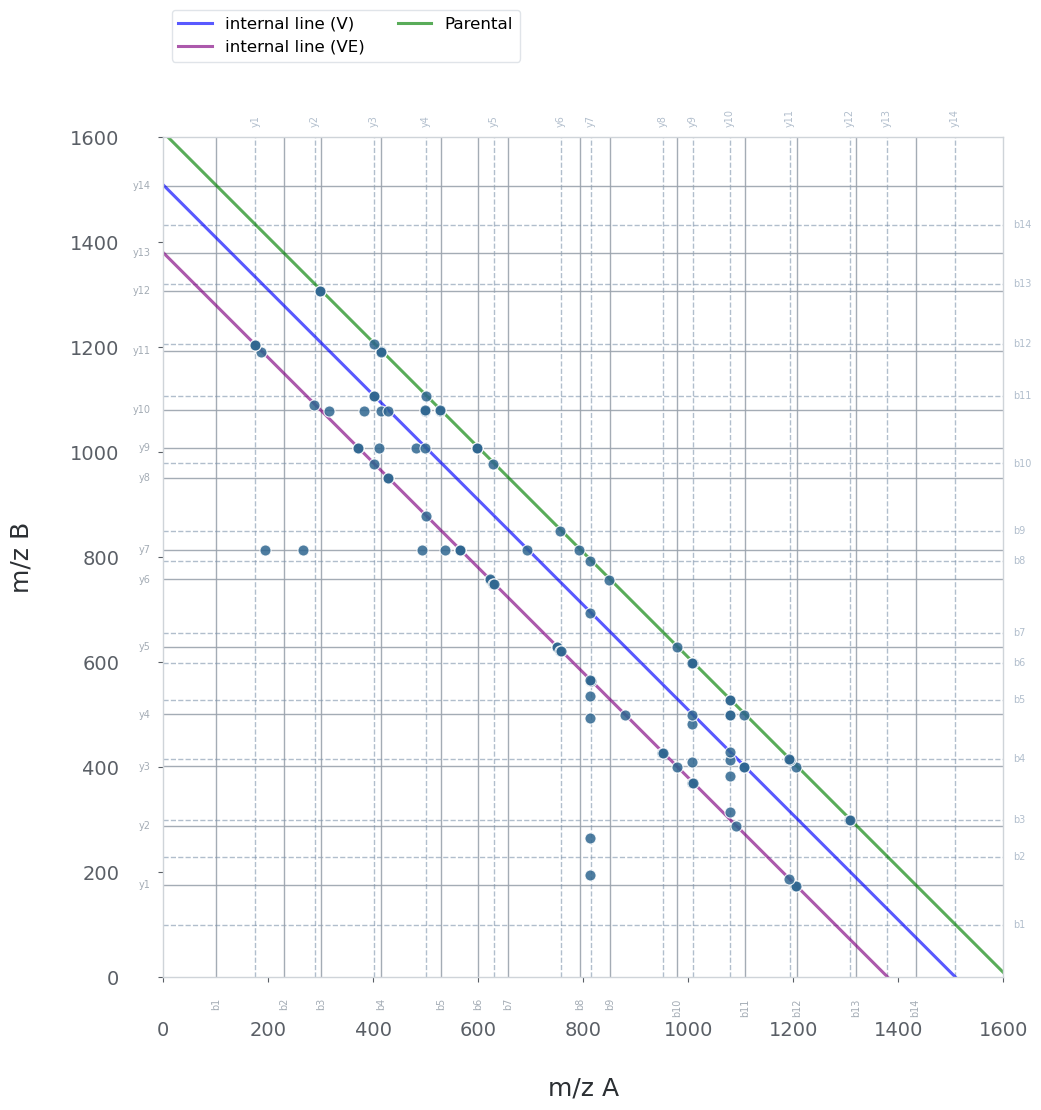

(<Figure size 1200x1200 with 1 Axes>, <Axes: xlabel='m/z A', ylabel='m/z B'>)

In [41]:
exact_lines = [
    {"slope": -1, "intercept": 1608.869 - 100.069, "color": "blue",   "label": "internal line (V)"},
    {"slope": -1, "intercept": 1608.869 - 229.112, "color": "purple", "label": "internal line (VE)"},
    {"slope": -1, "intercept": 1608.869, "color": "green", "label": "Parental"},
]


plot_ffc_map_simple_with_line(
    tffc_table_doubled,
    mz_a_col="tffc_A",
    mz_b_col="tffc_B",
    lines=exact_lines,
    b_ions=b_ions,
    y_ions=y_ions,
    start_from_zero=True,
    grid_alpha=0.9,
    grid_label_alpha=0.9,
    grid_label_fontsize=7,
    xlim=(0, 1600),
    ylim=(0, 1600)
)

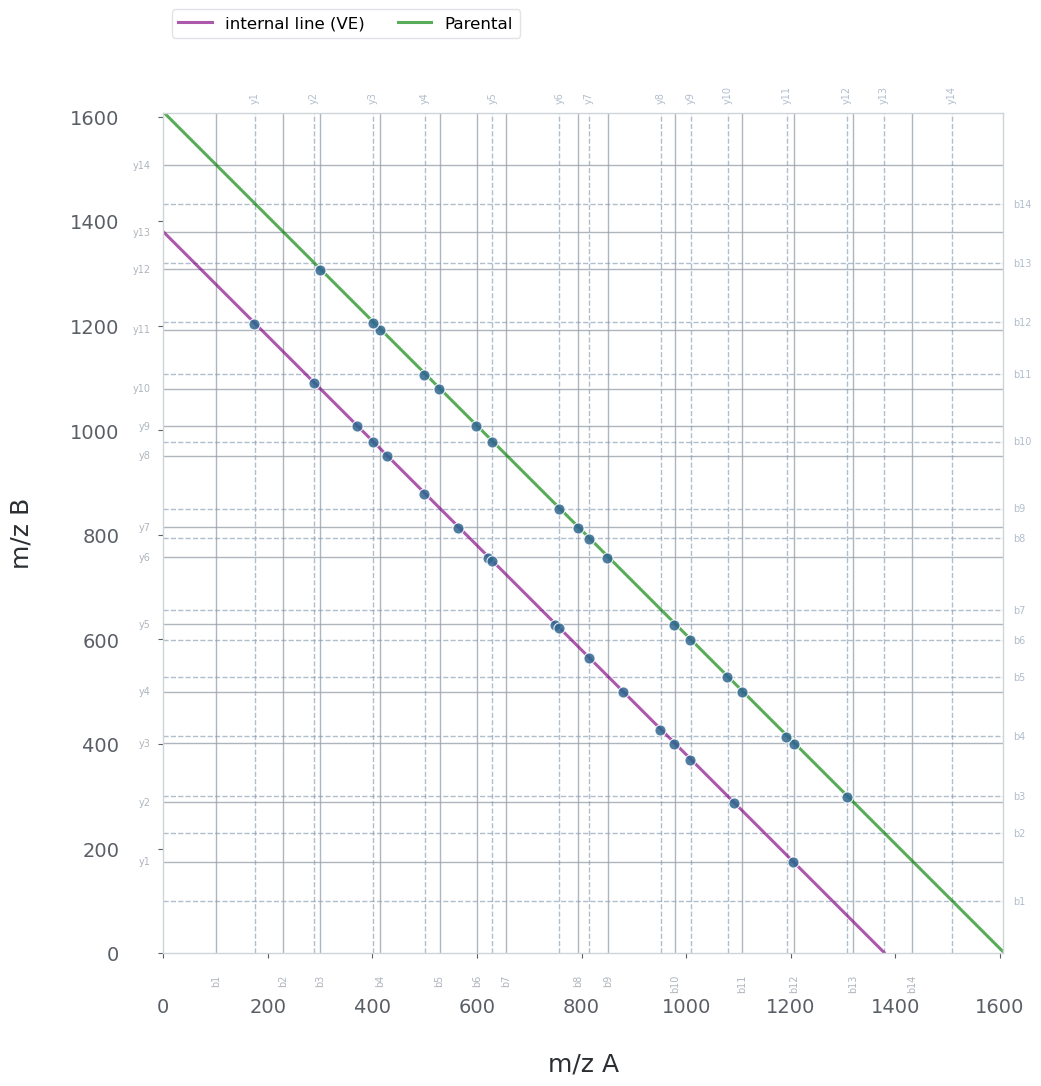

(<Figure size 1200x1200 with 1 Axes>, <Axes: xlabel='m/z A', ylabel='m/z B'>)

In [49]:
ranking_to_keep = [3, 9, 12, 10, 24, 36, 18, 34, 61, 7, 19, 2, 11, 5, 4, 13, 14, 1, 27] 
df_parent_tfcc = tffc_table_doubled[tffc_table_doubled["Ranking"].isin(ranking_to_keep)].copy()
exact_lines = [
    {"slope": -1, "intercept": 1608.869 - 229.112, "color": "purple", "label": "internal line (VE)"},
    {"slope": -1, "intercept": 1608.869, "color": "green", "label": "Parental"},
]

plot_ffc_map_simple_with_line(
    df_parent_tfcc,
    mz_a_col="tffc_A",
    mz_b_col="tffc_B",
    lines=exact_lines,
    b_ions=b_ions,
    y_ions=y_ions,
    start_from_zero=True,
    grid_alpha=0.8,
    grid_label_alpha=0.8,
    grid_label_fontsize=7,
)